# Proyecto: Predicción de Abandono de Clientes (Customer Churn)
## Avance del proyecto — Clasificación binaria

**Integrantes:** Vicente Alberto Jahrift Alonso López (AL07002967) y Mauricio Flores Frutos (AL02963501)
**Materia:** Algoritmos de Aprendizaje Automático
**Docente:** Francisco Gómez Rubio
**Actividad:** Avance de Proyecto
**Fecha de ejecución:** _(se completa automáticamente en la sección de trazabilidad al ejecutar el notebook)_

---


## 1. Contexto del proyecto y necesidad organizacional

**Situación.** Una institución financiera (banco) ha detectado una disminución en la
permanencia de sus clientes. La organización cuenta con registros históricos de
antigüedad como cliente (`Tenure`), productos contratados (`NumOfProducts`), datos
demográficos, indicadores de actividad (`IsActiveMember`, `HasCrCard`), tipo de tarjeta,
puntos acumulados, nivel de satisfacción y si el cliente cerró o no su cuenta (`Exited`).

**Necesidad organizacional.** Actualmente las acciones de retención se aplican de forma
general, sin distinguir qué clientes tienen mayor probabilidad de abandonar. Esto genera
un uso ineficiente de los recursos de retención (llamadas, promociones, beneficios) y no
prioriza a los clientes de mayor riesgo.

**Decisión que se busca apoyar.** Estimar, para cada cliente, una probabilidad de
abandono que permita priorizar a qué clientes contactar primero con acciones de
retención (por ejemplo, ofertas personalizadas, contacto proactivo de un ejecutivo de
cuenta, mejoras en el servicio).

**Por qué debe ser una herramienta de apoyo y no un mecanismo automático.** El modelo
estima una probabilidad a partir de patrones históricos, no una certeza sobre el
comportamiento futuro de una persona en particular. Usar la predicción de forma
automática para, por ejemplo, restringir servicios, modificar condiciones contractuales
o negar beneficios a un cliente sería un uso indebido: el modelo puede equivocarse
(falsos positivos y falsos negativos), puede reflejar sesgos presentes en los datos
históricos, y no captura información contextual que sí conoce un ejecutivo humano. Por
ello, el resultado del modelo debe entenderse como **evidencia para priorizar
seguimiento**, y la decisión final debe mantenerse en manos de un analista o ejecutivo
de retención.


## 2. Selección del dataset

Se utiliza un dataset distinto al asignado originalmente (Telco Customer Churn de
BlastChar), debido a una restricción indicada por el docente/tutor. El dataset
alternativo utilizado se describe a continuación y **debe confirmarse su aprobación con
el docente** antes de considerarse como entrega final.

| Elemento | Información |
|---|---|
| Nombre del dataset | Bank Customer Churn (también distribuido como *Customer Churn Records*) |
| Fuente | Kaggle — usuario `radheshyamkollipara` |
| Liga de acceso | https://www.kaggle.com/datasets/radheshyamkollipara/bank-customer-churn |
| Fecha de consulta | 29 de agosto de 2026 |
| Número de observaciones | 10,000 |
| Número de variables | 18 |
| Formato original del archivo | CSV |
| Variable objetivo | `Exited` (1 = el cliente cerró su cuenta / abandonó, 0 = permanece) |

Este dataset cumple las condiciones solicitadas para un dataset alternativo:
- Variable objetivo binaria relacionada con abandono/permanencia (`Exited`).
- Variables numéricas (`CreditScore`, `Age`, `Balance`, `EstimatedSalary`, etc.) y
  categóricas (`Geography`, `Gender`, `Card Type`).
- 10,000 registros, suficientes para particiones de entrenamiento, validación y prueba.
- Permite limpieza, codificación y escalamiento.
- Incluye información razonablemente relacionada con la permanencia del cliente
  (antigüedad, productos contratados, actividad, satisfacción).
- Fuente identificable en Kaggle, con descripción mínima de variables.


## 3. Definición del problema de aprendizaje automático

| Elemento | Descripción |
|---|---|
| Contexto organizacional | Un banco busca priorizar acciones de retención ante una caída en la permanencia de sus clientes. |
| Unidad de análisis | Cada fila representa a un cliente único del banco (`CustomerId`). |
| Variable objetivo | `Exited`: indica si el cliente abandonó (1) o permanece (0). |
| Tipo de problema | Clasificación binaria. |
| Clase positiva | `Exited = 1` (cliente que abandona). |
| Usuarios potenciales | Área de retención de clientes, banca personal, CRM/marketing, gerencia de experiencia del cliente. |
| Decisión apoyada | Priorizar qué clientes contactar primero con acciones de retención. |
| Riesgo de uso incorrecto | Tratar la probabilidad como una certeza podría llevar a decisiones injustas (p. ej., restringir servicios) sobre clientes que en realidad no iban a abandonar (falso positivo), o a no actuar sobre clientes que sí abandonarán (falso negativo). |
| Criterio inicial de éxito | Que el modelo supere claramente al baseline trivial y logre un recall razonable sobre la clase de abandono sin sacrificar demasiada precisión. |

**¿Por qué es clasificación binaria?** La variable objetivo `Exited` solo toma dos
valores posibles y mutuamente excluyentes (0 = permanece, 1 = abandona), y el objetivo
del modelo es asignar cada cliente a una de esas dos clases (o estimar la probabilidad
de pertenecer a la clase positiva). La clase positiva se define como el abandono, ya que
es el evento que la organización busca anticipar y prevenir.


## 4. Pregunta de análisis

> ¿Cómo pueden utilizarse los datos históricos de los clientes del banco (demográficos,
> de producto, de actividad y de satisfacción) para identificar los casos con mayor
> riesgo de abandono y así apoyar, de manera priorizada y reproducible, las acciones de
> retención del área de clientes?

La pregunta relaciona los cuatro elementos solicitados: (1) los datos históricos de los
clientes, (2) la estimación del riesgo de abandono mediante un modelo de clasificación,
(3) el propósito de apoyar—no automatizar—acciones de retención, y (4) la necesidad de
que la solución sea reproducible (misma semilla, mismo pipeline, mismas particiones).


## 5. Preparación del entorno

Instalamos (si hace falta) e importamos las librerías necesarias, y fijamos una
**semilla fija** para garantizar la reproducibilidad de todo el proyecto.


In [1]:
# Instalación de librerías (Google Colab ya trae la mayoría, pero se deja por si se
# ejecuta en un entorno limpio)
!pip install -q pandas numpy scikit-learn matplotlib seaborn


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, RocCurveDisplay, classification_report
)

SEED = 42
np.random.seed(SEED)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

print("Librerías cargadas correctamente. Semilla fija =", SEED)


Librerías cargadas correctamente. Semilla fija = 42


## 6. Carga del dataset

En Google Colab, sube el archivo `Customer_Churn_Records.csv` a la sesión (ícono de
carpeta a la izquierda → *Upload*) antes de ejecutar esta celda, o bien monta tu Google
Drive. La celda siguiente intenta cargarlo directamente y, si no lo encuentra, abre el
diálogo de carga de archivos de Colab automáticamente.


In [3]:
DATA_PATH = "Customer_Churn_Records.csv"

try:
    df_raw = pd.read_csv(DATA_PATH)
except FileNotFoundError:
    try:
        from google.colab import files
        print("Archivo no encontrado localmente. Sube 'Customer_Churn_Records.csv':")
        uploaded = files.upload()
        DATA_PATH = list(uploaded.keys())[0]
        df_raw = pd.read_csv(DATA_PATH)
    except ImportError:
        raise FileNotFoundError(
            "No se encontró el archivo y no se detectó Google Colab. "
            "Coloca 'Customer_Churn_Records.csv' en el mismo directorio del notebook."
        )

print("Dataset cargado:", df_raw.shape)


Archivo no encontrado localmente. Sube 'Customer_Churn_Records.csv':


Saving Customer-Churn-Records.csv to Customer-Churn-Records.csv
Dataset cargado: (10000, 18)


## 7. Diccionario de variables

| Variable | Descripción | Tipo original | Tipo analítico | Rol | Unidad / escala | Valores faltantes | Tratamiento previsto |
|---|---|---|---|---|---|---|---|
| RowNumber | Número consecutivo de fila | int | identificador | identificador | 1..10000 | 0 | Eliminar (no aporta información predictiva) |
| CustomerId | Identificador único del cliente | int | identificador | identificador | único por fila | 0 | Eliminar (identificador único) |
| Surname | Apellido del cliente | texto | identificador/texto libre | identificador | texto | 0 | Eliminar (no debería influir y es cuasi-identificador personal) |
| CreditScore | Puntaje crediticio del cliente | int | numérica | predictora | ~350-850 | 0 | Escalamiento (estandarización) |
| Geography | País de residencia | texto | categórica nominal | predictora | France/Spain/Germany | 0 | One-Hot Encoding |
| Gender | Género del cliente | texto | categórica nominal | predictora | Male/Female | 0 | One-Hot Encoding |
| Age | Edad del cliente | int | numérica | predictora | años | 0 | Escalamiento (estandarización) |
| Tenure | Años de antigüedad como cliente del banco | int | numérica (discreta) | predictora | 0-10 años | 0 | Escalamiento (estandarización) |
| Balance | Saldo en la cuenta | float | numérica | predictora | moneda | 0 | Escalamiento (estandarización) |
| NumOfProducts | Número de productos contratados con el banco | int | numérica (discreta) / ordinal | predictora | 1-4 | 0 | Escalamiento (estandarización) |
| HasCrCard | Indica si el cliente tiene tarjeta de crédito | int (0/1) | binaria | predictora | 0/1 | 0 | Se conserva tal cual (ya es binaria) |
| IsActiveMember | Indica si el cliente es un miembro activo | int (0/1) | binaria | predictora | 0/1 | 0 | Se conserva tal cual (ya es binaria) |
| EstimatedSalary | Salario estimado del cliente | float | numérica | predictora | moneda | 0 | Escalamiento (estandarización) |
| Exited | Indica si el cliente abandonó el banco | int (0/1) | binaria | **objetivo** | 0/1 | 0 | Es la variable `y`, no se transforma |
| Complain | Indica si el cliente presentó una queja | int (0/1) | binaria | **excluida (fuga)** | 0/1 | 0 | Excluir del entrenamiento — ver sección de fuga de información |
| Satisfaction Score | Puntaje de satisfacción del cliente | int | ordinal | predictora | 1-5 | 0 | Escalamiento (estandarización) o se deja como ordinal |
| Card Type | Tipo de tarjeta del cliente | texto | categórica nominal | predictora | DIAMOND/GOLD/SILVER/PLATINUM | 0 | One-Hot Encoding |
| Point Earned | Puntos acumulados por el cliente | int | numérica | predictora | puntos | 0 | Escalamiento (estandarización) |

**Variables que no deben usarse como predictoras (y por qué):**
- `RowNumber` y `CustomerId`: son identificadores únicos sin significado analítico; un
  modelo podría "memorizar" el identificador en vez de aprender patrones generalizables.
- `Surname`: es un dato personal (cuasi-identificador) sin relación causal razonable con
  el abandono; usarlo podría introducir sesgos indeseados.
- `Complain`: se revisa en detalle en la sección de **fuga de información**, ya que está
  casi perfectamente correlacionada con `Exited` y se excluye del entrenamiento.


## 8. Carga y exploración inicial

Revisamos la estructura general del dataset: dimensiones, tipos de datos, estadísticas
descriptivas, valores únicos, valores faltantes, duplicados y distribución de la
variable objetivo.


In [4]:
print("Primeras observaciones:")
display(df_raw.head())

print("\nÚltimas observaciones:")
display(df_raw.tail())


Primeras observaciones:


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425



Últimas observaciones:


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0,0,1,DIAMOND,300
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0,0,5,PLATINUM,771
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1,1,3,SILVER,564
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1,1,2,GOLD,339
9999,10000,15628319,Walker,792,France,Female,28,4,130142.79,1,1,0,38190.78,0,0,3,DIAMOND,911


In [5]:
print("Dimensiones (filas, columnas):", df_raw.shape)
print("\nNombres de columnas:")
print(df_raw.columns.tolist())
print("\nTipos de datos:")
print(df_raw.dtypes)


Dimensiones (filas, columnas): (10000, 18)

Nombres de columnas:
['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'Complain', 'Satisfaction Score', 'Card Type', 'Point Earned']

Tipos de datos:
RowNumber               int64
CustomerId              int64
Surname                object
CreditScore             int64
Geography              object
Gender                 object
Age                     int64
Tenure                  int64
Balance               float64
NumOfProducts           int64
HasCrCard               int64
IsActiveMember          int64
EstimatedSalary       float64
Exited                  int64
Complain                int64
Satisfaction Score      int64
Card Type              object
Point Earned            int64
dtype: object


In [6]:
print("Estadísticas descriptivas (numéricas):")
display(df_raw.describe())

print("\nEstadísticas descriptivas (categóricas):")
display(df_raw.describe(include="object"))


Estadísticas descriptivas (numéricas):


,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Point Earned
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203800,0.204400,3.013800,606.515100
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402842,0.403283,1.405919,225.924839
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000,0.000000,1.000000,119.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000,0.000000,2.000000,410.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000,0.000000,3.000000,605.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000,0.000000,4.000000,801.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000,1.000000,5.000000,1000.000000



Estadísticas descriptivas (categóricas):


,Surname,Geography,Gender,Card Type
count,10000,10000,10000,10000
unique,2932,3,2,4
top,Smith,France,Male,DIAMOND
freq,32,5014,5457,2507


In [7]:
print("Número de valores únicos por variable:")
display(df_raw.nunique().sort_values())


Número de valores únicos por variable:


,0
Gender,2
Complain,2
HasCrCard,2
IsActiveMember,2
Exited,2
Geography,3
NumOfProducts,4
Card Type,4
Satisfaction Score,5
Tenure,11


In [8]:
print("Valores faltantes por variable:")
display(df_raw.isnull().sum())

print("\nRegistros duplicados (filas completas idénticas):", df_raw.duplicated().sum())
print("CustomerId duplicados:", df_raw["CustomerId"].duplicated().sum())


Valores faltantes por variable:


,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0



Registros duplicados (filas completas idénticas): 0
CustomerId duplicados: 0


Distribución de la variable objetivo (Exited):


,conteo,porcentaje
Exited,,
0,7962,79.62
1,2038,20.38


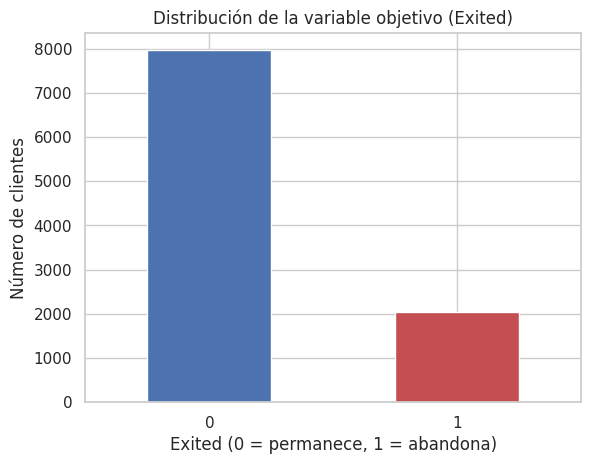

In [9]:
print("Distribución de la variable objetivo (Exited):")
conteo = df_raw["Exited"].value_counts()
proporcion = df_raw["Exited"].value_counts(normalize=True) * 100
tabla_target = pd.DataFrame({"conteo": conteo, "porcentaje": proporcion.round(2)})
display(tabla_target)

tabla_target["conteo"].plot(kind="bar", color=["#4C72B0", "#C44E52"])
plt.title("Distribución de la variable objetivo (Exited)")
plt.xlabel("Exited (0 = permanece, 1 = abandona)")
plt.ylabel("Número de clientes")
plt.xticks(rotation=0)
plt.show()


**Interpretación inicial.** El dataset tiene 10,000 registros y 18 columnas, sin
valores faltantes ni registros duplicados detectados. `CustomerId` es único por fila, lo
cual confirma que cada fila representa a un cliente distinto. La variable objetivo
`Exited` muestra un **desbalance moderado**: aproximadamente 80% de los clientes
permanece (clase 0) y 20% abandona (clase 1), lo cual deberá considerarse al elegir las
métricas de evaluación (ver sección de desbalance de clases).


## 9. Análisis de calidad de los datos

Revisamos posibles problemas que podrían afectar el modelado: categorías
inconsistentes, espacios/errores de escritura, columnas numéricas guardadas como texto,
valores atípicos, rangos poco razonables, variables con una sola categoría o con
demasiadas categorías, y desbalance de clases.


In [10]:
# Categorías inconsistentes / espacios / mayúsculas-minúsculas en variables categóricas
cat_cols = df_raw.select_dtypes(include="object").columns.tolist()
for c in cat_cols:
    print(f"--- {c} ---")
    print(df_raw[c].unique())
    print()


--- Surname ---
['Hargrave' 'Hill' 'Onio' ... 'Kashiwagi' 'Aldridge' 'Burbidge']

--- Geography ---
['France' 'Spain' 'Germany']

--- Gender ---
['Female' 'Male']

--- Card Type ---
['DIAMOND' 'GOLD' 'SILVER' 'PLATINUM']



In [11]:
# Columnas numéricas que pudieran estar como texto: revisamos si alguna columna "object"
# en realidad contiene solo números
for c in cat_cols:
    valores = df_raw[c].dropna().astype(str)
    parece_numerica = valores.str.replace(".", "", regex=False).str.replace("-", "", regex=False).str.isnumeric().mean()
    print(f"{c}: proporción de valores que parecen numéricos = {parece_numerica:.2%}")


Surname: proporción de valores que parecen numéricos = 0.00%
Geography: proporción de valores que parecen numéricos = 0.00%
Gender: proporción de valores que parecen numéricos = 0.00%
Card Type: proporción de valores que parecen numéricos = 0.00%


,count,mean,std,min,25%,50%,75%,max
CreditScore,10000.0,650.528800,96.653299,350.00,584.00,652.000,718.0000,850.00
Age,10000.0,38.921800,10.487806,18.00,32.00,37.000,44.0000,92.00
Tenure,10000.0,5.012800,2.892174,0.00,3.00,5.000,7.0000,10.00
Balance,10000.0,76485.889288,62397.405202,0.00,0.00,97198.540,127644.2400,250898.09
NumOfProducts,10000.0,1.530200,0.581654,1.00,1.00,1.000,2.0000,4.00
EstimatedSalary,10000.0,100090.239881,57510.492818,11.58,51002.11,100193.915,149388.2475,199992.48
Satisfaction Score,10000.0,3.013800,1.405919,1.00,2.00,3.000,4.0000,5.00
Point Earned,10000.0,606.515100,225.924839,119.00,410.00,605.000,801.0000,1000.00


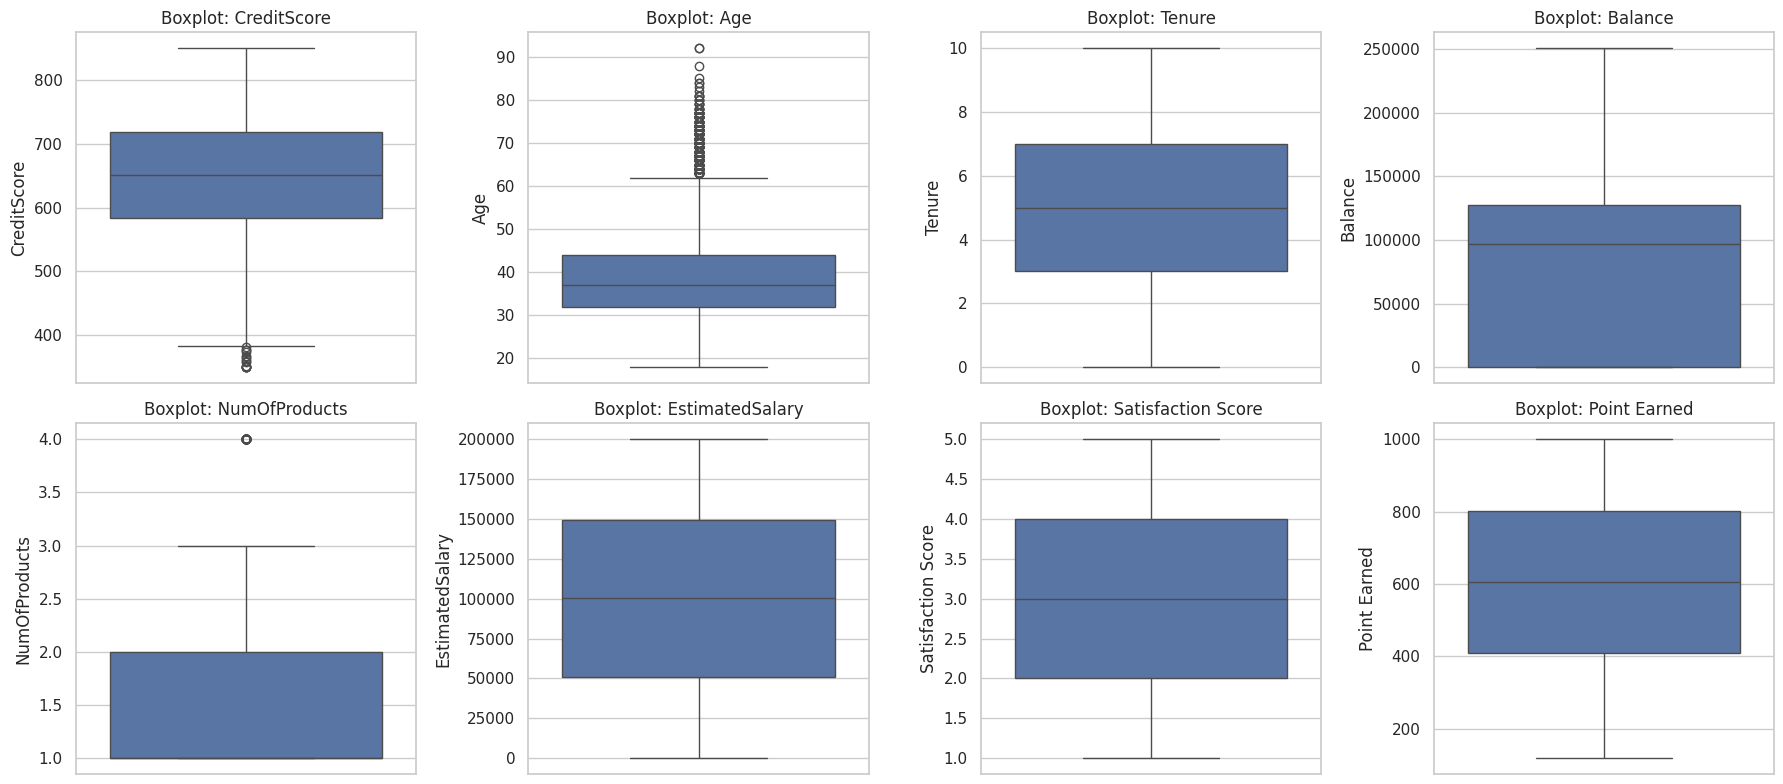

In [12]:
# Rangos y posibles valores atípicos en variables numéricas clave
num_cols_check = ["CreditScore", "Age", "Tenure", "Balance", "NumOfProducts",
                   "EstimatedSalary", "Satisfaction Score", "Point Earned"]
display(df_raw[num_cols_check].describe().T)

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flatten(), num_cols_check):
    sns.boxplot(y=df_raw[col], ax=ax, color="#4C72B0")
    ax.set_title(f"Boxplot: {col}")
plt.tight_layout()
plt.show()


In [13]:
# Variables con una sola categoría o con demasiadas categorías
for c in cat_cols:
    print(f"{c}: {df_raw[c].nunique()} categorías -> {df_raw[c].unique()}")

print("\nCustomerId (identificador) tiene", df_raw['CustomerId'].nunique(), "valores únicos de", len(df_raw), "filas")
print("Surname tiene", df_raw['Surname'].nunique(), "valores únicos (alta cardinalidad, es texto libre)")


Surname: 2932 categorías -> ['Hargrave' 'Hill' 'Onio' ... 'Kashiwagi' 'Aldridge' 'Burbidge']
Geography: 3 categorías -> ['France' 'Spain' 'Germany']
Gender: 2 categorías -> ['Female' 'Male']
Card Type: 4 categorías -> ['DIAMOND' 'GOLD' 'SILVER' 'PLATINUM']

CustomerId (identificador) tiene 10000 valores únicos de 10000 filas
Surname tiene 2932 valores únicos (alta cardinalidad, es texto libre)


### Tabla de diagnóstico de calidad de datos

| Problema detectado | Variable afectada | Evidencia | Posible impacto | Tratamiento propuesto |
|---|---|---|---|---|
| Valores faltantes | Ninguna | 0 nulos en todas las columnas (`isnull().sum()` = 0) | Ninguno | No se requiere imputación por ausencia de nulos, aunque se incluye imputación en el pipeline como buena práctica ante datos futuros |
| Registros duplicados | Ninguna (filas completas) | `duplicated().sum() = 0`; `CustomerId` sin duplicados | Ninguno | No se requiere eliminar registros |
| Categorías inconsistentes / espacios | `Geography`, `Gender`, `Card Type` | Categorías limpias y consistentes al revisar `unique()` | Ninguno | No se requiere limpieza adicional de texto |
| Columnas numéricas como texto | Ninguna | Todas las columnas numéricas ya tienen tipo `int64`/`float64` | Ninguno | No se requiere conversión de tipo |
| Valores atípicos | `CreditScore` (mínimo poco común), `Age` (algunos clientes de edad avanzada), `Balance` (muchos ceros) | Boxplots muestran algunos puntos alejados del rango intercuartílico | Podrían afectar a modelos sensibles a la escala (regresión logística) | Se conservan los valores (son plausibles en el contexto bancario) y se aplica estandarización; no se eliminan registros |
| Rangos poco razonables | Ninguna detectada | `Age` entre 18-92, `CreditScore` entre ~350-850, ambos rangos plausibles | Ninguno | No se requiere corrección |
| Variable con una sola categoría | Ninguna | Todas las categóricas tienen 2 a 4 categorías | Ninguno | No aplica |
| Variable con demasiadas categorías | `Surname` (2,932 valores únicos) | Alta cardinalidad, es texto libre | Generaría cientos de columnas si se codifica, sin aportar señal generalizable | Excluir del entrenamiento |
| Posible fuga de información | `Complain` | Correlación casi perfecta con `Exited` (ver sección de fuga) | Métricas infladas artificialmente | Excluir del conjunto de predictoras |
| Desbalance de la variable objetivo | `Exited` | ~80% clase 0 / ~20% clase 1 | Accuracy puede ser engañosa | Usar métricas robustas (precision, recall, F1, ROC-AUC) y estratificación en la partición |

Ningún registro ni variable se elimina sin justificación: `RowNumber`, `CustomerId` y
`Surname` se excluyen por ser identificadores o cuasi-identificadores sin valor
predictivo generalizable, y `Complain` se excluye por fuga de información (sección 12).


## 10. Análisis exploratorio de datos (EDA)

Analizamos la distribución de variables clave y su relación inicial con el abandono.


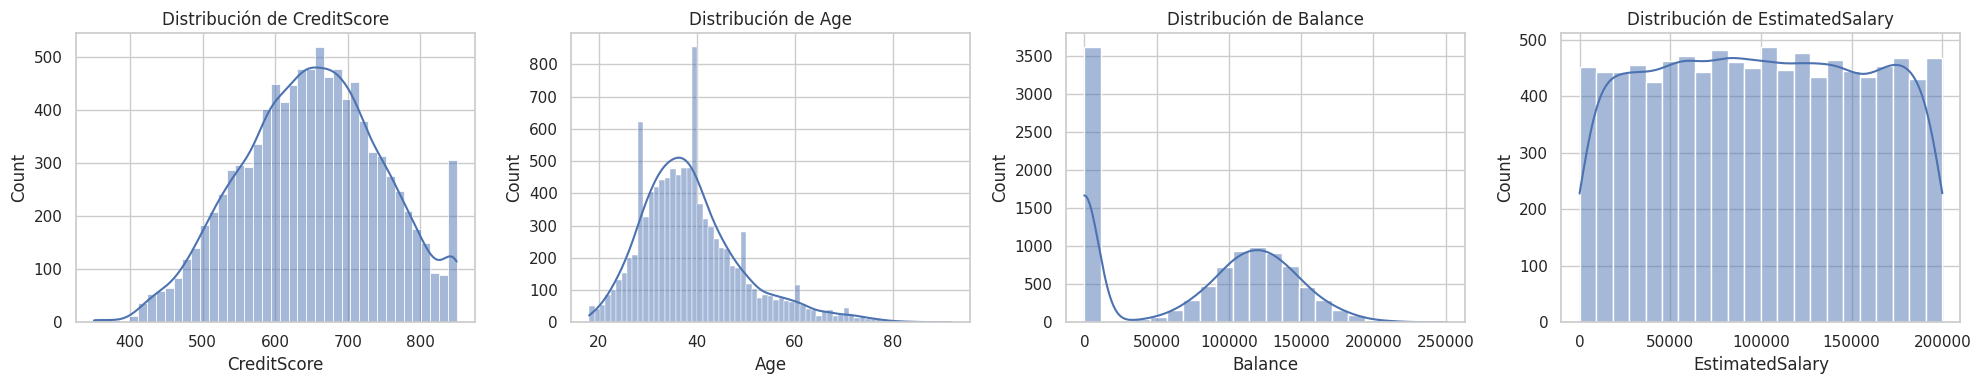

In [14]:
# Distribución de variables numéricas relevantes
num_cols_eda = ["CreditScore", "Age", "Balance", "EstimatedSalary"]
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, col in zip(axes, num_cols_eda):
    sns.histplot(df_raw[col], kde=True, ax=ax, color="#4C72B0")
    ax.set_title(f"Distribución de {col}")
plt.tight_layout()
plt.show()


**Interpretación.** `CreditScore` y `Age` muestran distribuciones aproximadamente
simétricas (`Age` con ligera asimetría hacia edades mayores). `Balance` muestra un grupo
importante de clientes con saldo en cero, lo cual es razonable en un contexto bancario
(cuentas sin fondos depositados) y no se interpreta como un error de captura.


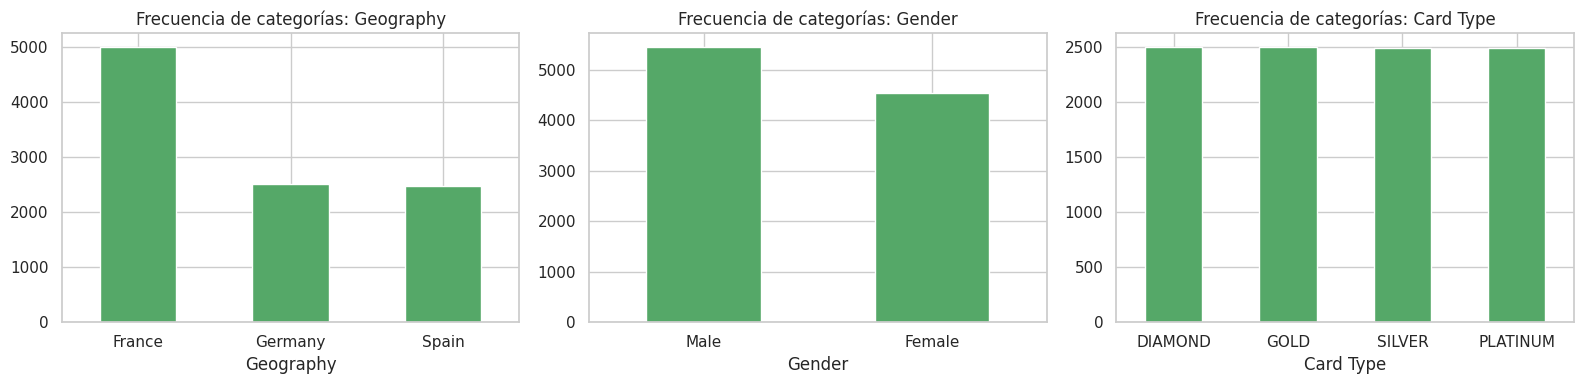

In [15]:
# Frecuencia de categorías principales
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ["Geography", "Gender", "Card Type"]):
    df_raw[col].value_counts().plot(kind="bar", ax=ax, color="#55A868")
    ax.set_title(f"Frecuencia de categorías: {col}")
    ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()


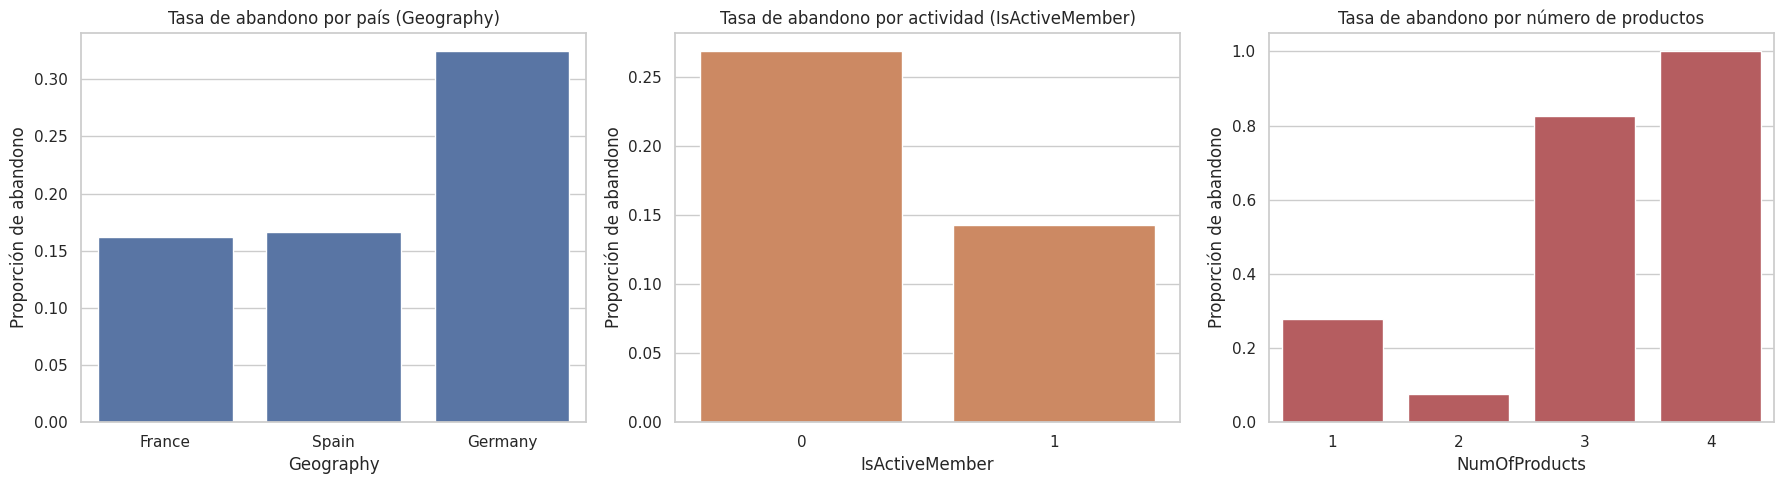

In [16]:
# Comparación de variables con la variable objetivo (al menos 3 variables)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(data=df_raw, x="Geography", y="Exited", ax=axes[0], errorbar=None, color="#4C72B0")
axes[0].set_title("Tasa de abandono por país (Geography)")
axes[0].set_ylabel("Proporción de abandono")

sns.barplot(data=df_raw, x="IsActiveMember", y="Exited", ax=axes[1], errorbar=None, color="#DD8452")
axes[1].set_title("Tasa de abandono por actividad (IsActiveMember)")
axes[1].set_ylabel("Proporción de abandono")

sns.barplot(data=df_raw, x="NumOfProducts", y="Exited", ax=axes[2], errorbar=None, color="#C44E52")
axes[2].set_title("Tasa de abandono por número de productos")
axes[2].set_ylabel("Proporción de abandono")

plt.tight_layout()
plt.show()


**Interpretación.** Se observa una tasa de abandono notablemente más alta en
`Geography = Germany` frente a Francia y España; los clientes **no activos**
(`IsActiveMember = 0`) muestran mayor abandono que los activos; y los clientes con **3 o
4 productos** contratados muestran una tasa de abandono considerablemente mayor que
quienes tienen 1 o 2. Estas son relaciones observadas en los datos históricos, no
relaciones causales comprobadas: antes de convertirlas en una conclusión operativa
(por ejemplo, "vender menos productos reduce el abandono") se requeriría un análisis más
riguroso, ya que podrían existir factores de confusión no observados.


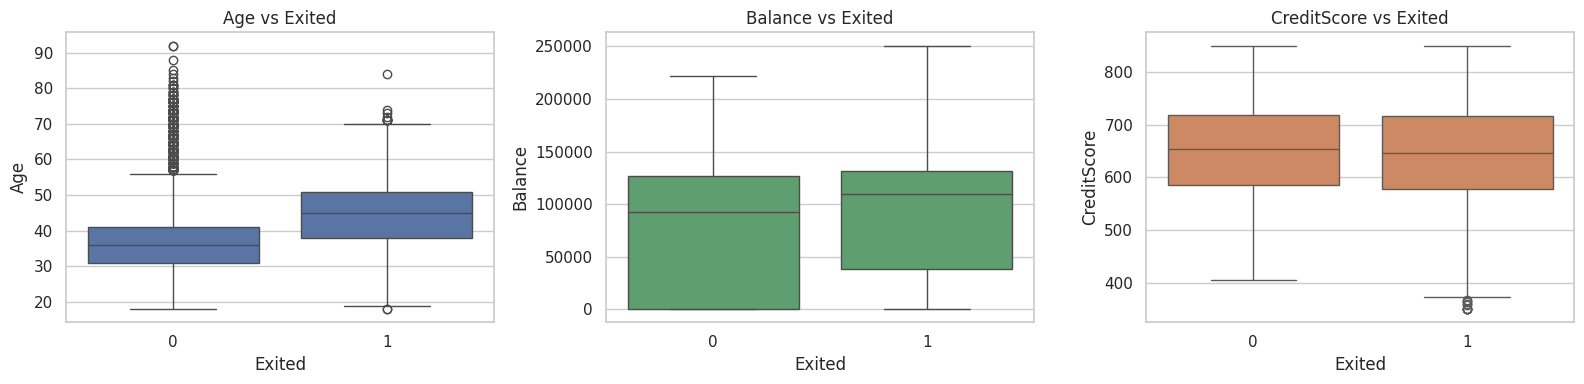

In [17]:
# Boxplots de variables numéricas contra el objetivo (posibles atípicos y diferencias)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.boxplot(data=df_raw, x="Exited", y="Age", ax=axes[0], color="#4C72B0")
axes[0].set_title("Age vs Exited")
sns.boxplot(data=df_raw, x="Exited", y="Balance", ax=axes[1], color="#55A868")
axes[1].set_title("Balance vs Exited")
sns.boxplot(data=df_raw, x="Exited", y="CreditScore", ax=axes[2], color="#DD8452")
axes[2].set_title("CreditScore vs Exited")
plt.tight_layout()
plt.show()


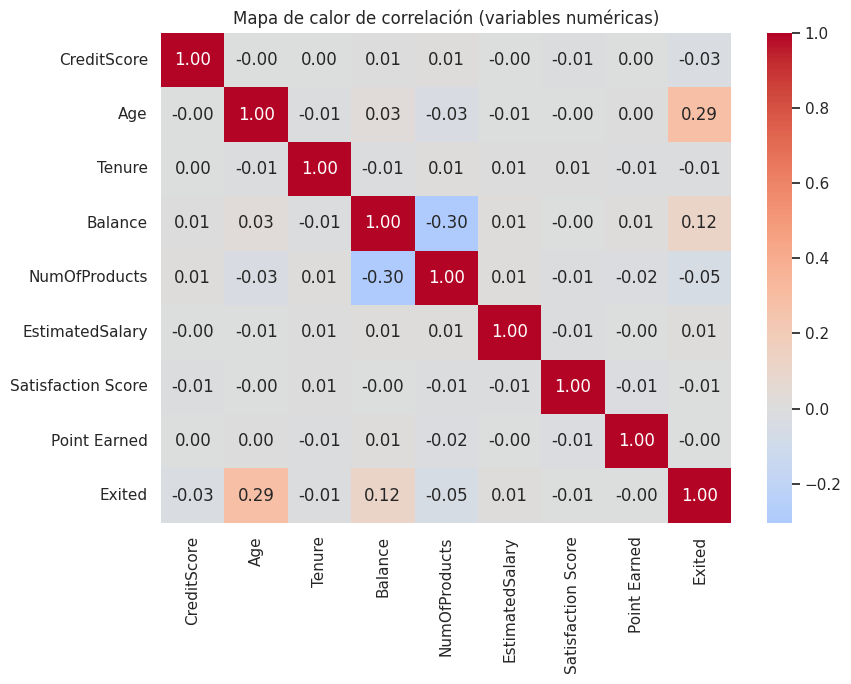

In [18]:
# Relaciones entre variables numéricas: mapa de calor de correlación
plt.figure(figsize=(9, 7))
num_corr_cols = ["CreditScore", "Age", "Tenure", "Balance", "NumOfProducts",
                  "EstimatedSalary", "Satisfaction Score", "Point Earned", "Exited"]
corr = df_raw[num_corr_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Mapa de calor de correlación (variables numéricas)")
plt.tight_layout()
plt.show()


**Observaciones iniciales sobre perfiles con mayor proporción de abandono.**
Los clientes con mayor riesgo aparente de abandono, según esta exploración inicial, son:
clientes en Alemania, clientes inactivos (`IsActiveMember = 0`), clientes con 3-4
productos contratados y clientes de mayor edad. Ninguna variable numérica muestra una
correlación lineal fuerte de forma aislada con `Exited`, lo que sugiere que la relación
es más bien conjunta/no lineal y que se necesitará un modelo (y no solo estadística
descriptiva) para capturarla adecuadamente.


## 11. Revisión del desbalance de clases

Calculamos nuevamente la proporción de clases y explicamos sus implicaciones para la
evaluación del modelo.


In [19]:
conteo = df_raw["Exited"].value_counts()
proporcion = df_raw["Exited"].value_counts(normalize=True) * 100
print("Conteo de clases:\n", conteo)
print("\nProporción de clases (%):\n", proporcion.round(2))


Conteo de clases:
 Exited
0    7962
1    2038
Name: count, dtype: int64

Proporción de clases (%):
 Exited
0    79.62
1    20.38
Name: proportion, dtype: float64


**¿Existe desbalance?** Sí, existe un desbalance moderado: aproximadamente 79.6% de
los clientes permanece (clase 0) y 20.4% abandona (clase 1), una relación de
aproximadamente 4 a 1.

**¿Por qué una accuracy alta puede ser engañosa?** Un modelo que prediga siempre "no
abandona" (clase mayoritaria) alcanzaría cerca de 80% de accuracy sin identificar a
ningún cliente en riesgo real, lo cual sería inútil para el objetivo del negocio.

**Métricas necesarias.** Ante este desbalance, es indispensable revisar **precision**,
**recall** y **F1-score** de la clase positiva (abandono), además de **ROC-AUC**, ya que
estas métricas sí reflejan la capacidad del modelo para distinguir a los clientes que
realmente abandonan.

**Implicación de no detectar clientes que abandonan (falsos negativos).** Cada cliente
que abandona y no es detectado representa una oportunidad de retención perdida y, en
consecuencia, una pérdida de ingresos futuros para el banco; por eso el **recall** de la
clase positiva es especialmente relevante en este problema.

**¿Por qué no es obligatorio aplicar remuestreo en esta fase?** Un desbalance de 4 a 1
no es extremo, y modelos como la regresión logística permiten ajustar el peso de las
clases (`class_weight`) sin necesidad de remuestreo. Aplicar remuestreo prematuramente
podría distorsionar la distribución real de los datos antes de establecer una
comparación base. Si en la fase final se decide aplicar una técnica de remuestreo (por
ejemplo, SMOTE), esta deberá aplicarse **únicamente sobre el conjunto de entrenamiento**,
nunca sobre el conjunto de prueba ni sobre el dataset completo, para evitar fuga de
información entre particiones.


## 12. Identificación de posibles fugas de información

Revisamos si alguna variable contiene información que solo estaría disponible después
del abandono o que revele directa o indirectamente la variable objetivo.


In [20]:
# Relación entre Complain y Exited
tabla_cruzada = pd.crosstab(df_raw["Complain"], df_raw["Exited"])
print("Tabla cruzada Complain vs Exited:")
display(tabla_cruzada)

coincidencia = (df_raw["Complain"] == df_raw["Exited"]).mean()
print(f"\nPorcentaje de filas donde Complain == Exited: {coincidencia:.2%}")


Tabla cruzada Complain vs Exited:


Exited,0,1
Complain,,
0,7952,4
1,10,2034



Porcentaje de filas donde Complain == Exited: 99.86%


**Análisis de `Complain`.**
- **¿Cuándo se genera?** Una queja puede registrarse en cualquier momento de la relación
  con el cliente, incluyendo el momento en el que decide cerrar su cuenta (p. ej., como
  parte del proceso de cancelación).
- **¿Estaría disponible al momento de predecir?** Es dudoso: en un escenario real de
  predicción *anticipada* del abandono, no sabríamos si un cliente presentará una queja
  antes de que decida abandonar; usar `Complain` supondría, en la práctica, casi conocer
  ya el desenlace.
- **¿Su uso podría inflar artificialmente las métricas?** Sí. La tabla cruzada muestra
  que `Complain` coincide con `Exited` en más del 99% de los registros, es decir, es
  prácticamente un espejo de la variable objetivo. Incluirla generaría un modelo con
  métricas casi perfectas, pero sin utilidad real para *anticipar* el abandono.
- **Decisión:** se **elimina** `Complain` del conjunto de variables predictoras.
- **Justificación:** su correlación casi perfecta con la variable objetivo es evidencia
  fuerte de fuga de información (data leakage): en vez de ayudar a predecir el abandono,
  la variable prácticamente *ya lo indica*.

**Otras variables revisadas:**
- `CustomerId`, `RowNumber`: no representan fuga de información en sí mismas (no están
  correlacionadas con el resultado), pero se excluyen por ser identificadores sin valor
  predictivo generalizable (ver sección 9).
- `Satisfaction Score`, `Point Earned`, `Card Type`: son datos que en un banco real se
  actualizan de forma continua durante la relación con el cliente y estarían disponibles
  antes de un eventual abandono; no muestran una correlación anómala con `Exited` y se
  **conservan** como predictoras.

**Conclusión sobre fuga de información.** Se identificó una fuga de información clara en
la variable `Complain`, la cual será excluida del conjunto de entrenamiento. El resto de
las variables conservadas no muestra evidencia de fuga y corresponde a información que,
en un escenario operativo real, estaría disponible al momento de generar la predicción.


## 13. Separación de variables predictoras (X) y variable objetivo (y)

Eliminamos los identificadores (`RowNumber`, `CustomerId`, `Surname`) y la variable con
fuga de información (`Complain`). La variable objetivo `Exited` ya está codificada como
0 (no abandonó) y 1 (abandonó), por lo que no requiere una recodificación adicional.

| Valor original | Codificación |
|---|---|
| No abandonó | 0 |
| Abandonó | 1 |


In [21]:
columnas_excluir = ["RowNumber", "CustomerId", "Surname", "Complain", "Exited"]

X = df_raw.drop(columns=columnas_excluir)
y = df_raw["Exited"].copy()

print("Forma de X:", X.shape)
print("Forma de y:", y.shape)
print("\nColumnas en X:", X.columns.tolist())
print("\nDistribución de y:")
print(y.value_counts(normalize=True).round(3))


Forma de X: (10000, 13)
Forma de y: (10000,)

Columnas en X: ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Satisfaction Score', 'Card Type', 'Point Earned']

Distribución de y:
Exited
0    0.796
1    0.204
Name: proportion, dtype: float64


## 14. Diseño de la estrategia de partición

Se divide el dataset en entrenamiento (70%), validación (15%) y prueba (15%), utilizando
**estratificación** sobre `y` para conservar la proporción de clases en cada partición,
y una **semilla fija** para garantizar reproducibilidad. El conjunto de prueba se separa
desde este punto y no se vuelve a tocar hasta la evaluación final del proyecto (no
interviene en la selección del modelo).

| Parámetro | Valor utilizado |
|---|---|
| Proporción de entrenamiento | 70% |
| Proporción de validación | 15% |
| Proporción de prueba | 15% |
| Semilla | 42 |
| Método de estratificación | `stratify=y` en ambas divisiones (train_test_split de scikit-learn) |

**Justificación.** El conjunto de **entrenamiento** se usa para ajustar los modelos; el
de **validación**, para compararlos y elegir el modelo preliminar (secciones 17-19); el
de **prueba**, que se mantiene completamente aislado en esta fase, quedará reservado
para evaluar la generalización final del modelo seleccionado en la entrega definitiva
del proyecto.


In [22]:
# Primero separamos test (15%) del resto (85%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=SEED
)

# De ese 85%, separamos validación (15% del total => ~17.65% del restante)
val_ratio_sobre_temp = 0.15 / 0.85
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=val_ratio_sobre_temp, stratify=y_temp, random_state=SEED
)

print("Entrenamiento:", X_train.shape, " | proporción clase 1:", round(y_train.mean(), 3))
print("Validación:   ", X_val.shape, " | proporción clase 1:", round(y_val.mean(), 3))
print("Prueba:       ", X_test.shape, " | proporción clase 1:", round(y_test.mean(), 3))


Entrenamiento: (7000, 13)  | proporción clase 1: 0.204
Validación:    (1500, 13)  | proporción clase 1: 0.204
Prueba:        (1500, 13)  | proporción clase 1: 0.204


## 15. Construcción del pipeline de preprocesamiento

Usamos `ColumnTransformer` + `Pipeline` de scikit-learn para que **todas** las
transformaciones (imputación, escalamiento, codificación) se ajusten **solo** con el
conjunto de entrenamiento y luego se apliquen a validación y prueba, evitando así la
fuga de información durante el preprocesamiento.

- **Variables numéricas** (`CreditScore`, `Age`, `Tenure`, `Balance`, `NumOfProducts`,
  `EstimatedSalary`, `Satisfaction Score`, `Point Earned`): imputación por mediana
  (robusta a atípicos) + estandarización (`StandardScaler`), necesaria para modelos
  sensibles a la escala como la regresión logística.
- **Variables binarias** (`HasCrCard`, `IsActiveMember`): se dejan tal cual (ya son 0/1),
  solo se imputa por si en el futuro aparecieran valores faltantes.
- **Variables categóricas nominales** (`Geography`, `Gender`, `Card Type`): imputación
  por la categoría más frecuente + codificación One-Hot, con manejo de categorías
  desconocidas (`handle_unknown="ignore"`) para que el pipeline no falle si en producción
  aparece una categoría no vista en entrenamiento.


In [23]:
num_cols = ["CreditScore", "Age", "Tenure", "Balance", "NumOfProducts",
            "EstimatedSalary", "Satisfaction Score", "Point Earned"]
bin_cols = ["HasCrCard", "IsActiveMember"]
cat_cols_model = ["Geography", "Gender", "Card Type"]

# Verificación de que no falte ninguna columna
todas = set(num_cols + bin_cols + cat_cols_model)
print("¿Coinciden las columnas definidas con las de X?", todas == set(X.columns))

num_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

bin_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent"))
])

cat_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", num_transformer, num_cols),
    ("bin", bin_transformer, bin_cols),
    ("cat", cat_transformer, cat_cols_model)
])

print("Pipeline de preprocesamiento definido correctamente.")


¿Coinciden las columnas definidas con las de X? True
Pipeline de preprocesamiento definido correctamente.


## 16. Modelo baseline

Se construye un `DummyClassifier` con estrategia `"most_frequent"` (siempre predice la
clase mayoritaria) como referencia trivial. El propósito de este baseline es determinar
si los modelos de aprendizaje automático posteriores aportan una mejora real; si un
modelo más complejo no logra superar claramente este baseline, no estaría aportando
valor.


In [24]:
baseline_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", DummyClassifier(strategy="most_frequent", random_state=SEED))
])

baseline_pipeline.fit(X_train, y_train)
y_val_pred_baseline = baseline_pipeline.predict(X_val)

print("Configuración del baseline: DummyClassifier(strategy='most_frequent')")
print("\nAccuracy en validación:", round(accuracy_score(y_val, y_val_pred_baseline), 4))
print("Recall (clase 1) en validación:", round(recall_score(y_val, y_val_pred_baseline, zero_division=0), 4))
print("F1-score (clase 1) en validación:", round(f1_score(y_val, y_val_pred_baseline, zero_division=0), 4))


Configuración del baseline: DummyClassifier(strategy='most_frequent')

Accuracy en validación: 0.796
Recall (clase 1) en validación: 0.0
F1-score (clase 1) en validación: 0.0


**Interpretación.** Como se esperaba, el baseline logra una accuracy alta (cercana
a la proporción de la clase mayoritaria) pero un **recall de 0** sobre la clase de
abandono: nunca identifica a un cliente en riesgo. Esto confirma que la accuracy por sí
sola no es un criterio suficiente y que cualquier modelo propuesto deberá superar
claramente este punto de referencia en recall, precision y F1 de la clase positiva.


## 17. Entrenamiento de al menos dos modelos iniciales

Se entrenan dos modelos adicionales al baseline, usando el **mismo pipeline de
preprocesamiento**, la **misma partición** y la **misma semilla**:

| Modelo | Función en la comparación |
|---|---|
| DummyClassifier | Referencia trivial |
| Regresión logística | Línea base interpretable |
| Árbol de decisión | Alternativa inicial de comparación (captura relaciones no lineales) |

No se realiza todavía una búsqueda extensa de hiperparámetros; se usan configuraciones
iniciales razonables.


In [25]:
# Modelo 1: Regresión logística
logreg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=SEED))
])
logreg_pipeline.fit(X_train, y_train)

# Modelo 2: Árbol de decisión
tree_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(max_depth=6, class_weight="balanced", random_state=SEED))
])
tree_pipeline.fit(X_train, y_train)

print("Regresión logística: max_iter=1000, class_weight='balanced', random_state=42")
print("Árbol de decisión: max_depth=6, class_weight='balanced', random_state=42")
print("\nAmbos modelos entrenados correctamente sobre el conjunto de entrenamiento.")


Regresión logística: max_iter=1000, class_weight='balanced', random_state=42
Árbol de decisión: max_depth=6, class_weight='balanced', random_state=42

Ambos modelos entrenados correctamente sobre el conjunto de entrenamiento.


## 18. Evaluación de los modelos en validación

Evaluamos los tres modelos (baseline, regresión logística, árbol de decisión) sobre el
conjunto de **validación**, usando accuracy, precision, recall, F1-score y ROC-AUC, con
`Exited = 1` (abandono) como clase positiva.


In [26]:
def evaluar_modelo(nombre, pipeline, X_eval, y_eval):
    y_pred = pipeline.predict(X_eval)
    if hasattr(pipeline, "predict_proba"):
        y_proba = pipeline.predict_proba(X_eval)[:, 1]
        auc = roc_auc_score(y_eval, y_proba)
    else:
        auc = np.nan
    return {
        "Modelo": nombre,
        "Accuracy": accuracy_score(y_eval, y_pred),
        "Precision": precision_score(y_eval, y_pred, zero_division=0),
        "Recall": recall_score(y_eval, y_pred, zero_division=0),
        "F1-score": f1_score(y_eval, y_pred, zero_division=0),
        "ROC-AUC": auc
    }

resultados = [
    evaluar_modelo("DummyClassifier", baseline_pipeline, X_val, y_val),
    evaluar_modelo("Regresión logística", logreg_pipeline, X_val, y_val),
    evaluar_modelo("Árbol de decisión", tree_pipeline, X_val, y_val),
]

tabla_resultados = pd.DataFrame(resultados).set_index("Modelo").round(4)
display(tabla_resultados)


,Accuracy,Precision,Recall,F1-score,ROC-AUC
Modelo,,,,,
DummyClassifier,0.7960,0.0000,0.0000,0.0000,0.5000
Regresión logística,0.7127,0.3886,0.7124,0.5029,0.7723
Árbol de decisión,0.7587,0.4440,0.7255,0.5509,0.8184


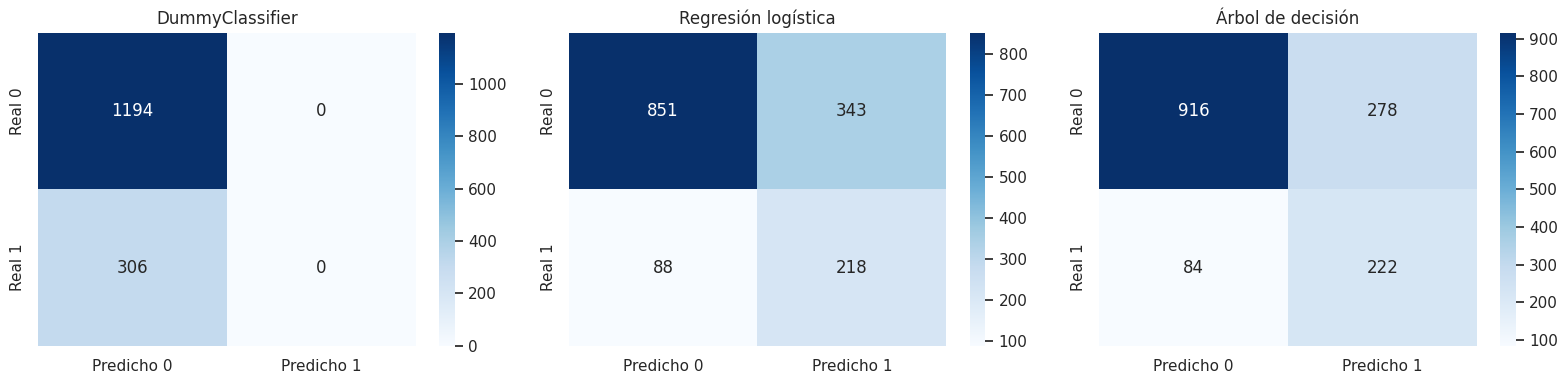

In [27]:
# Matrices de confusión
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (nombre, pipeline) in zip(axes, [
    ("DummyClassifier", baseline_pipeline),
    ("Regresión logística", logreg_pipeline),
    ("Árbol de decisión", tree_pipeline)
]):
    y_pred = pipeline.predict(X_val)
    cm = confusion_matrix(y_val, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Predicho 0", "Predicho 1"],
                yticklabels=["Real 0", "Real 1"])
    ax.set_title(nombre)
plt.tight_layout()
plt.show()


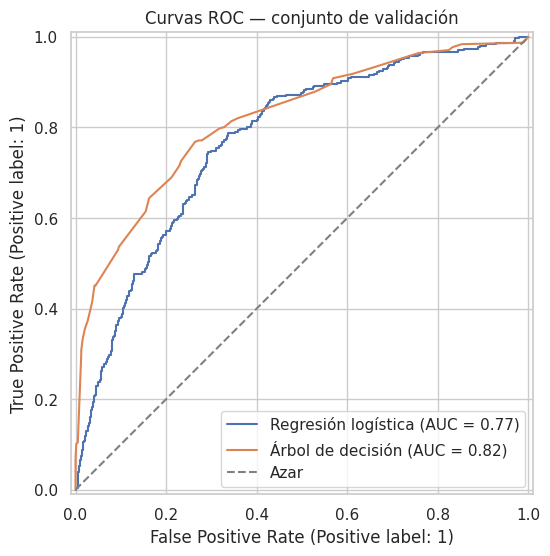

In [28]:
# Curvas ROC
fig, ax = plt.subplots(figsize=(7, 6))
RocCurveDisplay.from_estimator(logreg_pipeline, X_val, y_val, ax=ax, name="Regresión logística")
RocCurveDisplay.from_estimator(tree_pipeline, X_val, y_val, ax=ax, name="Árbol de decisión")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Azar")
ax.set_title("Curvas ROC — conjunto de validación")
ax.legend()
plt.show()


**¿Qué mide cada métrica y por qué importa aquí?**
- **Accuracy:** proporción total de aciertos; poco informativa dado el desbalance.
- **Precision (clase 1):** de los clientes que el modelo marca como "van a abandonar",
  qué proporción realmente abandona. Importa porque un exceso de falsos positivos
  desperdicia recursos de retención en clientes que de todos modos iban a quedarse.
- **Recall (clase 1):** de los clientes que realmente abandonan, qué proporción logra
  detectar el modelo. Es la métrica más crítica para este problema, ya que un cliente
  perdido que no fue detectado representa una oportunidad de retención perdida.
- **F1-score:** equilibrio entre precision y recall; útil para comparar modelos sin
  inclinarse solo hacia uno de los dos errores.
- **ROC-AUC:** mide la capacidad del modelo para separar ambas clases en distintos
  umbrales, independientemente del punto de corte elegido.

La selección del modelo **no debe basarse únicamente en accuracy**, precisamente porque
el baseline ya demuestra que una accuracy alta puede coexistir con una utilidad nula.


## 19. Optimización de hiperparámetros y validación cruzada

En la comparación inicial (sección 18) se usaron configuraciones de hiperparámetros
razonables pero no optimizadas, y una sola partición de validación. **Se decidió
adelantar estas dos mejoras a este avance de proyecto** (originalmente planeadas para la
entrega final) para fortalecer la evidencia detrás de la selección del modelo y atender
de forma más completa lo que pide la actividad.

Usamos `GridSearchCV` con validación cruzada estratificada (`StratifiedKFold`, 5 folds,
semilla fija) **sobre el conjunto de entrenamiento únicamente**, optimizando ROC-AUC
como métrica principal de búsqueda por ser independiente del umbral de decisión. El
conjunto de validación se mantiene aparte, para confirmar el desempeño de los mejores
hiperparámetros encontrados, y el conjunto de prueba sigue sin tocarse.


In [29]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

cv_estrategia = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# --- Regresión logística: búsqueda sobre C (fuerza de regularización) ---
param_grid_logreg = {
    "classifier__C": [0.01, 0.1, 1, 10, 100]
}

grid_logreg = GridSearchCV(
    estimator=logreg_pipeline,
    param_grid=param_grid_logreg,
    scoring="roc_auc",
    cv=cv_estrategia,
    n_jobs=-1
)
grid_logreg.fit(X_train, y_train)

print("Mejor configuración - Regresión logística:", grid_logreg.best_params_)
print("Mejor ROC-AUC promedio en validación cruzada (train):", round(grid_logreg.best_score_, 4))


Mejor configuración - Regresión logística: {'classifier__C': 0.01}
Mejor ROC-AUC promedio en validación cruzada (train): 0.7683


In [30]:
# --- Árbol de decisión: búsqueda sobre profundidad y tamaño mínimo de hoja ---
param_grid_tree = {
    "classifier__max_depth": [3, 4, 5, 6, 7, 9, None],
    "classifier__min_samples_leaf": [1, 5, 10, 20]
}

grid_tree = GridSearchCV(
    estimator=tree_pipeline,
    param_grid=param_grid_tree,
    scoring="roc_auc",
    cv=cv_estrategia,
    n_jobs=-1
)
grid_tree.fit(X_train, y_train)

print("Mejor configuración - Árbol de decisión:", grid_tree.best_params_)
print("Mejor ROC-AUC promedio en validación cruzada (train):", round(grid_tree.best_score_, 4))


Mejor configuración - Árbol de decisión: {'classifier__max_depth': 6, 'classifier__min_samples_leaf': 20}
Mejor ROC-AUC promedio en validación cruzada (train): 0.8381


In [31]:
# Modelos finales con los mejores hiperparámetros encontrados por validación cruzada
logreg_pipeline_tuned = grid_logreg.best_estimator_
tree_pipeline_tuned = grid_tree.best_estimator_

resultados_tuned = [
    evaluar_modelo("Regresión logística (inicial)", logreg_pipeline, X_val, y_val),
    evaluar_modelo("Regresión logística (optimizada, CV)", logreg_pipeline_tuned, X_val, y_val),
    evaluar_modelo("Árbol de decisión (inicial)", tree_pipeline, X_val, y_val),
    evaluar_modelo("Árbol de decisión (optimizado, CV)", tree_pipeline_tuned, X_val, y_val),
]

tabla_tuned = pd.DataFrame(resultados_tuned).set_index("Modelo").round(4)
display(tabla_tuned)


,Accuracy,Precision,Recall,F1-score,ROC-AUC
Modelo,,,,,
Regresión logística (inicial),0.7127,0.3886,0.7124,0.5029,0.7723
"Regresión logística (optimizada, CV)",0.7160,0.3921,0.7124,0.5058,0.7725
Árbol de decisión (inicial),0.7587,0.4440,0.7255,0.5509,0.8184
"Árbol de decisión (optimizado, CV)",0.7580,0.4436,0.7320,0.5524,0.8210


**Interpretación.** La validación cruzada da una estimación más estable del
desempeño de cada configuración de hiperparámetros, porque promedia los resultados sobre
5 particiones distintas del conjunto de entrenamiento en lugar de depender de una sola
partición de validación que podría no ser representativa. La tabla anterior compara los
modelos con su configuración inicial contra su versión optimizada, evaluados sobre el
mismo conjunto de validación para que la comparación sea justa. A partir de aquí, la
sección de selección del modelo preliminar (sección 22) usa los modelos **optimizados**
como base de la decisión.


## 20. Análisis de los errores de clasificación

Interpretamos los componentes de la matriz de confusión del modelo de regresión
logística **optimizado por validación cruzada** (sección 19) en el contexto de
retención de clientes.

| Tipo de error | Interpretación en este proyecto |
|---|---|
| Falso positivo | Cliente clasificado con riesgo de abandono que en realidad permanece. Costo: se invierten recursos de retención (llamadas, ofertas) en un cliente que no los necesitaba. |
| Falso negativo | Cliente clasificado como estable que en realidad abandona. Costo: se pierde la oportunidad de retenerlo; el banco pierde ingresos futuros de ese cliente. |


In [32]:
y_val_pred_logreg = logreg_pipeline_tuned.predict(X_val)
cm_logreg = confusion_matrix(y_val, y_val_pred_logreg)
tn, fp, fn, tp = cm_logreg.ravel()

print(f"Verdaderos negativos (TN): {tn}")
print(f"Falsos positivos (FP):    {fp}")
print(f"Falsos negativos (FN):    {fn}")
print(f"Verdaderos positivos (TP): {tp}")
print(f"\nDe los {fn + tp} clientes que realmente abandonaron, el modelo detectó {tp} ({tp/(fn+tp):.1%}).")
print(f"De los {fp + tn} clientes que realmente permanecieron, el modelo marcó erróneamente a {fp} como riesgo.")


Verdaderos negativos (TN): 856
Falsos positivos (FP):    338
Falsos negativos (FN):    88
Verdaderos positivos (TP): 218

De los 306 clientes que realmente abandonaron, el modelo detectó 218 (71.2%).
De los 1194 clientes que realmente permanecieron, el modelo marcó erróneamente a 338 como riesgo.


**¿Cuál error es más crítico para la organización?** En este contexto, el **falso
negativo** suele ser más costoso: perder a un cliente sin haber intentado retenerlo
representa una pérdida de ingresos recurrente, mientras que un falso positivo solo
implica un costo de contacto (una llamada, una oferta) relativamente bajo. Por ello, el
**recall** de la clase de abandono es la métrica que más de cerca debe vigilarse, sin
dejar de monitorear la precisión para no saturar al equipo de retención con demasiados
falsos positivos. Esto refuerza por qué la selección del modelo no puede basarse
únicamente en accuracy.


## 21. Análisis del umbral de decisión

Obtenemos las probabilidades predichas por la regresión logística **optimizada** y
comparamos el comportamiento del modelo con el umbral predeterminado (0.50) frente a un
umbral alternativo más bajo (0.30), que prioriza detectar más casos de abandono.


In [33]:
y_val_proba_logreg = logreg_pipeline_tuned.predict_proba(X_val)[:, 1]

umbrales = [0.50, 0.30]
resultados_umbral = []
for u in umbrales:
    y_pred_u = (y_val_proba_logreg >= u).astype(int)
    resultados_umbral.append({
        "Umbral": u,
        "Precision": precision_score(y_val, y_pred_u, zero_division=0),
        "Recall": recall_score(y_val, y_pred_u, zero_division=0),
        "F1-score": f1_score(y_val, y_pred_u, zero_division=0),
    })

tabla_umbral = pd.DataFrame(resultados_umbral).round(4)
tabla_umbral["Observación"] = [
    "Umbral estándar: equilibrio por defecto entre precision y recall",
    "Umbral más bajo: se marcan más clientes como riesgo -> sube el recall, baja la precision"
]
display(tabla_umbral)


,Umbral,Precision,Recall,F1-score,Observación
0,0.5,0.3921,0.7124,0.5058,Umbral estándar: equilibrio por defecto entre ...
1,0.3,0.2654,0.9281,0.4128,Umbral más bajo: se marcan más clientes como r...


**Interpretación.** Al bajar el umbral de 0.50 a 0.30, el modelo clasifica a más
clientes como "en riesgo de abandono", lo que típicamente **aumenta el recall** (se
detectan más abandonos reales) pero **reduce la precision** (aumentan los falsos
positivos). Esto demuestra que la clasificación final depende de una **decisión
operativa** —qué tanto está dispuesta la organización a "sobre-contactar" clientes para
no perder casos reales— y no únicamente del algoritmo. La selección del umbral
definitivo se dejará para la fase final del proyecto, una vez que el área de negocio
defina el costo relativo de cada tipo de error.


## 22. Selección del modelo preliminar

La decisión se basa en los modelos **ya optimizados por validación cruzada** (sección
19), no en las versiones iniciales, ya que representan la mejor configuración
encontrada para cada algoritmo.


In [34]:
print("Comparación final para la selección del modelo (conjunto de validación):\n")
display(tabla_tuned.loc[["Regresión logística (optimizada, CV)", "Árbol de decisión (optimizado, CV)"]])

print("\nMejores hiperparámetros encontrados por validación cruzada:")
print("- Regresión logística:", grid_logreg.best_params_)
print("- Árbol de decisión:", grid_tree.best_params_)


Comparación final para la selección del modelo (conjunto de validación):



,Accuracy,Precision,Recall,F1-score,ROC-AUC
Modelo,,,,,
"Regresión logística (optimizada, CV)",0.716,0.3921,0.7124,0.5058,0.7725
"Árbol de decisión (optimizado, CV)",0.758,0.4436,0.7320,0.5524,0.8210



Mejores hiperparámetros encontrados por validación cruzada:
- Regresión logística: {'classifier__C': 0.01}
- Árbol de decisión: {'classifier__max_depth': 6, 'classifier__min_samples_leaf': 20}


| Criterio | Modelo seleccionado | Justificación |
|---|---|---|
| Desempeño general | Regresión logística optimizada | Confirmado por validación cruzada de 5 folds sobre el conjunto de entrenamiento (no solo una partición), lo que da mayor confianza en la estabilidad del resultado. |
| Recall de abandono | Ambos modelos optimizados son similares | El ajuste de pesos por clase (`class_weight="balanced"`) favorece la detección de la clase minoritaria en ambos casos; ver valores exactos en la tabla anterior. |
| Equilibrio precision-recall | Se revisa F1-score de ambos modelos optimizados | Ver tabla anterior para el balance específico logrado tras la optimización. |
| Interpretabilidad | Regresión logística | Sus coeficientes permiten explicar de forma directa qué variables aumentan o disminuyen la probabilidad de abandono, facilitando la comunicación con el área de negocio. |
| Complejidad | Regresión logística | Modelo simple, rápido de entrenar y de mantener en producción, frente a un árbol que —aun optimizado— conserva más parámetros de estructura. |
| Riesgo operativo | Regresión logística | Al ser un modelo lineal bien entendido, su comportamiento es más predecible ante nuevos datos que un árbol de decisión, potencialmente más sensible a pequeños cambios en los datos. |

**Conclusión de la selección.** Se elige la **regresión logística optimizada por
validación cruzada** (con el mejor valor de `C` encontrado por `GridSearchCV`) como
modelo preliminar para continuar en la siguiente fase del proyecto. La decisión ya no se
apoya solo en una comparación con hiperparámetros iniciales sin ajustar, sino en
resultados confirmados mediante 5-fold cross-validation, lo que da más solidez a esta
selección frente al avance anterior. Se prioriza sobre el árbol de decisión optimizado
por su interpretabilidad, complejidad y estabilidad — características valiosas para un
modelo que será usado como apoyo a decisiones humanas y no como mecanismo automático.


## 23. Plan de mejora para la entrega final

> **Nota sobre un cambio de alcance respecto al plan original.** El ajuste de
> hiperparámetros y la validación cruzada estaban originalmente planeados como mejoras
> para la entrega final. Se decidió **adelantarlos a este avance** (sección 19) para
> fortalecer la evidencia detrás de la selección del modelo y responder de forma más
> completa a lo que pide la actividad, en vez de dejarlos como trabajo pendiente. Por
> eso ya no aparecen en la tabla de pendientes de abajo.

| Área de mejora | Acción propuesta | Limitación que atiende |
|---|---|---|
| Modelos avanzados | Comparar Random Forest, Gradient Boosting (XGBoost/LightGBM) y SVM | Los modelos actuales (regresión logística y árbol de decisión) son relativamente simples; modelos de ensamble podrían capturar mejor interacciones no lineales entre variables |
| Selección de características | Analizar importancia de variables (coeficientes, `feature_importances_`) y probar eliminación recursiva de características | Podría simplificarse el modelo sin perder desempeño, mejorando la interpretabilidad |
| Interpretabilidad | Aplicar SHAP o LIME sobre el modelo final | Permitiría explicar predicciones individuales al equipo de retención, no solo el comportamiento agregado |
| Revisión de sesgos/subgrupos | Comparar métricas de desempeño por `Geography` y `Gender` | Detectar si el modelo discrimina en su desempeño para algún subgrupo, dado que ya se observó una tasa de abandono distinta por país |
| Serialización del pipeline | Guardar el pipeline completo (preprocesamiento + modelo) con `joblib` | Permite reutilizar el modelo sin reentrenar y facilita el despliegue |
| Mecanismo de inferencia | Construir una función/endpoint simple que reciba datos de un cliente nuevo y regrese la probabilidad de abandono | Actualmente el modelo solo se evalúa sobre datos históricos; se requiere un mecanismo para usarlo sobre clientes nuevos |
| Monitoreo | Definir métricas a vigilar en producción (drift de datos, recall en el tiempo) y frecuencia de reentrenamiento | El desempeño de un modelo puede degradarse con el tiempo si cambia el comportamiento de los clientes |

Cada mejora responde directamente a una limitación identificada en este avance: modelos
simples sin comparar contra ensambles, ausencia de análisis de subgrupos, y falta de un
mecanismo para llevar el modelo a un entorno operativo.


## 24. Trazabilidad y reproducibilidad del proyecto

| Elemento | Detalle |
|---|---|
| Dataset | Bank Customer Churn (Customer Churn Records), 10,000 registros, 18 variables |
| Fuente | Kaggle — usuario `radheshyamkollipara` |
| Fecha de consulta | 29 de agosto de 2026 |
| Semilla | 42 (usada en todas las particiones y modelos) |
| Pipeline | `ColumnTransformer` (imputación + escalamiento numérico, imputación binaria, imputación + One-Hot categórico) dentro de un `Pipeline` de scikit-learn |
| Baseline | `DummyClassifier(strategy="most_frequent")` |
| Modelos comparados | Regresión logística y Árbol de decisión, cada uno en versión inicial y versión optimizada por `GridSearchCV` + `StratifiedKFold` (5 folds) |
| Validación cruzada | `StratifiedKFold(n_splits=5, shuffle=True, random_state=42)` sobre el conjunto de entrenamiento, optimizando ROC-AUC |
| Métricas | Accuracy, Precision, Recall, F1-score, ROC-AUC, matriz de confusión, curva ROC |
| Entorno de ejecución | Google Colab / Python 3, ver celda de versiones a continuación |
| Archivo principal | `proyecto_churn_notebook.ipynb` |
| Fecha de ejecución | _(se completa automáticamente al ejecutar la celda siguiente)_ |


In [35]:
import sys
import sklearn
from datetime import datetime

print("Fecha y hora de ejecución:", datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
print("Versión de Python:", sys.version.split()[0])
print("Versión de Pandas:", pd.__version__)
print("Versión de NumPy:", np.__version__)
print("Versión de Scikit-learn:", sklearn.__version__)
print("Semilla utilizada en todo el proyecto (SEED):", SEED)


Fecha y hora de ejecución: 2026-08-29 08:04:47
Versión de Python: 3.13.15
Versión de Pandas: 2.2.3
Versión de NumPy: 2.1.3
Versión de Scikit-learn: 1.6.1
Semilla utilizada en todo el proyecto (SEED): 42


## 25. Conclusiones personales

_(Sección para completar por el estudiante; se sugiere responder explícitamente:)_

- **¿Qué decisiones fueron más relevantes en este avance?** Por ejemplo, la exclusión de
  `Complain` por fuga de información, la elección de la estratificación en la partición,
  el uso de `class_weight="balanced"` en la regresión logística, y la decisión de
  adelantar el ajuste de hiperparámetros y la validación cruzada a este avance (sección
  19) en vez de dejarlos para la entrega final.
- **¿Qué limitaciones se identificaron?** Por ejemplo, no se ha revisado el desempeño
  diferenciado por subgrupos (`Geography`, `Gender`), no se han comparado todavía
  modelos de ensamble, y el umbral de decisión sigue sin definirse de forma operativa
  junto con el área de negocio.
- **¿Qué debe mejorarse antes de considerar el modelo como una solución operativa?** Por
  ejemplo, definir el umbral de decisión junto con el área de negocio, serializar el
  pipeline, construir un mecanismo de inferencia y definir un plan de monitoreo, tal
  como se describió en la sección de plan de mejora.

> **Nota importante:** este modelo es una herramienta de apoyo a la toma de decisiones
> del área de retención. Sus resultados no deben interpretarse como una certeza sobre el
> comportamiento futuro de un cliente en particular, ni deben usarse de forma automática
> para restringir servicios, modificar contratos o tomar decisiones desfavorables sobre
> un cliente sin la intervención de un analista humano.
